In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
import math
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [3]:
data = pd.read_csv("heart.csv")


In [4]:
print(data.shape, data.dtypes, data.isna(), data.describe())

(1025, 14) age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object         age    sex     cp  trestbps   chol    fbs  restecg  thalach  exang  \
0     False  False  False     False  False  False    False    False  False   
1     False  False  False     False  False  False    False    False  False   
2     False  False  False     False  False  False    False    False  False   
3     False  False  False     False  False  False    False    False  False   
4     False  False  False     False  False  False    False    False  False   
...     ...    ...    ...       ...    ...    ...      ...      ...    ...   
1020  False  False  False     False  False  False    False    False  False   
1021  False  False  False     False  False  False    False    False  Fa

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


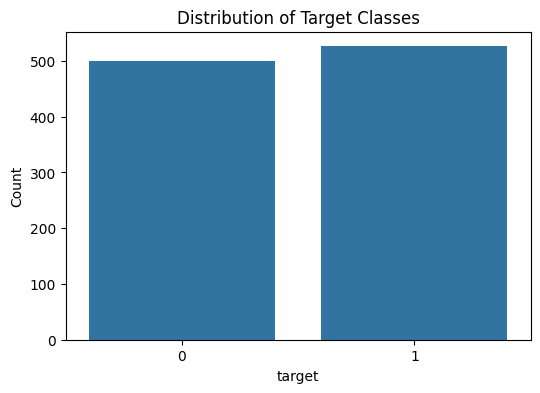

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=data)

plt.title("Distribution of Target Classes")
plt.xlabel("target")
plt.ylabel("Count")
plt.show()

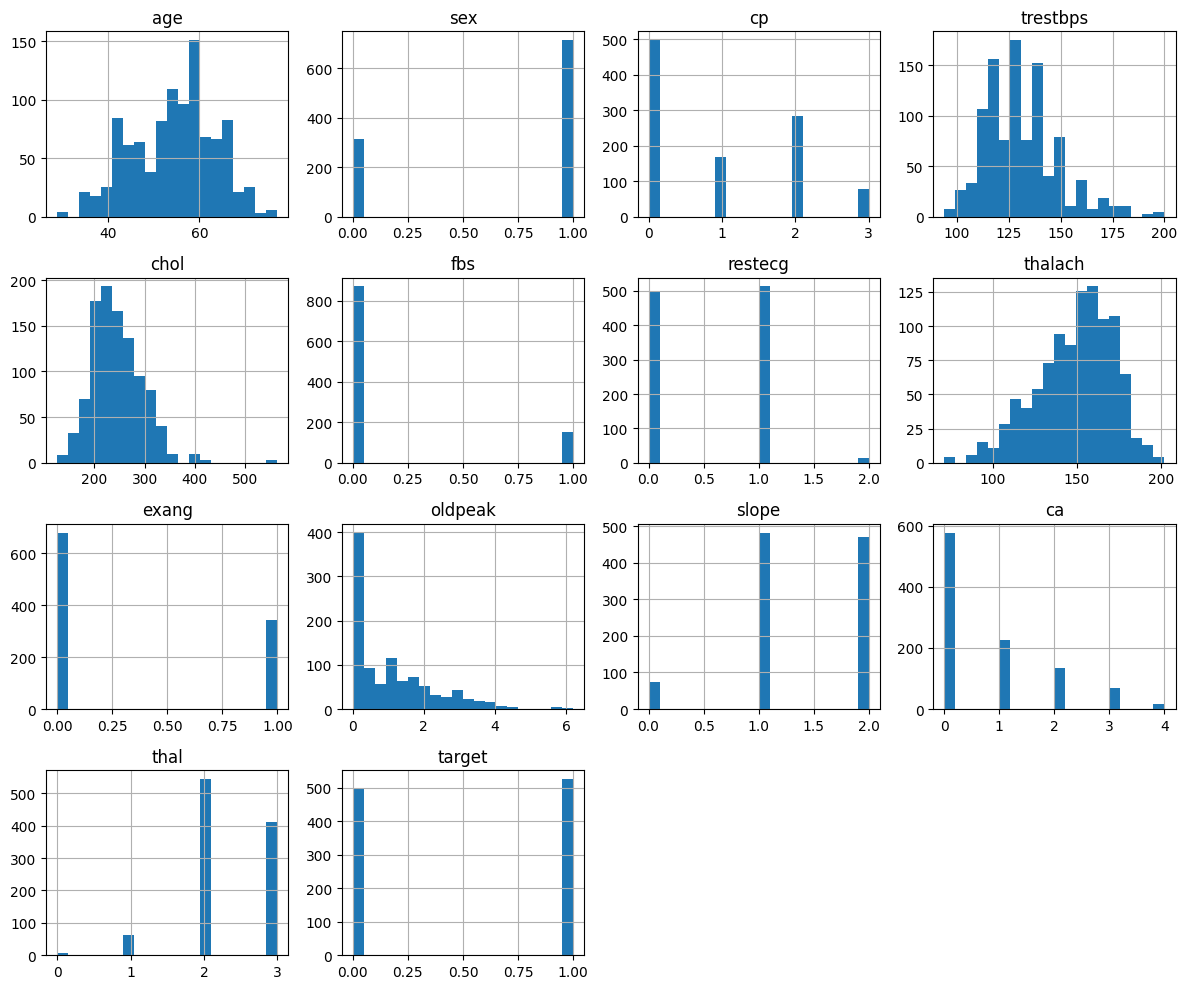

In [8]:
data.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

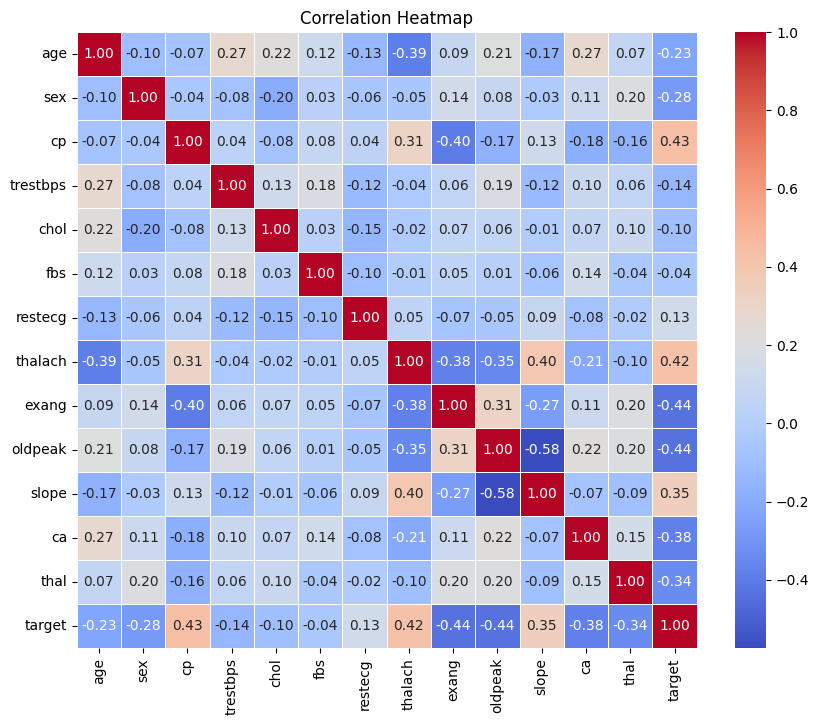

In [9]:
plt.figure(figsize=(10,8))

correlation_matrix = data.corr()

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [10]:
print(data.isnull().values.any())

# No null values hence no imputation required

False


In [11]:
from sklearn.preprocessing import StandardScaler

X = data.drop(columns=["target"])
y=data["target"]


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns) #This is tp convert X_scaled to a dataframe

print(X_scaled.head())

        age       sex        cp  trestbps      chol       fbs   restecg  \
0 -0.268437  0.661504 -0.915755 -0.377636 -0.659332 -0.418878  0.891255   
1 -0.158157  0.661504 -0.915755  0.479107 -0.833861  2.387330 -1.004049   
2  1.716595  0.661504 -0.915755  0.764688 -1.396233 -0.418878  0.891255   
3  0.724079  0.661504 -0.915755  0.936037 -0.833861 -0.418878  0.891255   
4  0.834359 -1.511706 -0.915755  0.364875  0.930822  2.387330  0.891255   

    thalach     exang   oldpeak     slope        ca      thal  
0  0.821321 -0.712287 -0.060888  0.995433  1.209221  1.089852  
1  0.255968  1.403928  1.727137 -2.243675 -0.731971  1.089852  
2 -1.048692  1.403928  1.301417 -2.243675 -0.731971  1.089852  
3  0.516900 -0.712287 -0.912329  0.995433  0.238625  1.089852  
4 -1.874977 -0.712287  0.705408 -0.624121  2.179817 -0.522122  


## Logistic Regressiom from Scratch

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.25,random_state=42)

In [13]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def cost_function(y_true, y_pred):
    epsilon = 1e-15 # this will be our lower bound for the value of the log loss function so that we can avoid log (0)
    y_pred = np.clip(y_pred,epsilon,1-epsilon)
    return -np.mean(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred)) # -ve was taken common from the formula hence outside, rest same formula as studied in theory 

In [14]:
def compute_gradient(x,y,w,b):
    x = np.array(x)
    y = np.array(y).reshape(-1)
    
    m = x.shape[0]
    n_features = x.shape[1] if len(x.shape) > 1 else 1
    dj_dw = np.zeros(n_features)
    dj_db = 0
    
    for i in range(m):
        x_i = x[i]
        f_wb = sigmoid(np.dot(x_i, w) + b)
        dj_db += f_wb - y[i]
        dj_dw += (f_wb - y[i]) * x_i
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db

In [15]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    m = len(x)
    J_history = []
    w_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function,keep the original w_in unchanged
    b = b_in
    
    for i in range(num_iters):

            dj_dw, dj_db = gradient_function(x, y, w, b )

            w = w - alpha * dj_dw
            b = b - alpha * dj_db

            if i<100000:      
                cost =  cost_function(x, y, w, b)
                J_history.append(cost)

            
            if i% math.ceil(num_iters/10) == 0:
                w_history.append(w)
                print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")

    return w, b, J_history, w_history

In [16]:
initial_w = np.zeros(X_scaled.shape[1])
initial_b = 0.


iterations = 1500
alpha = 0.01


def logistic_cost(x, y, w, b):
    y_pred = sigmoid(np.dot(np.array(x), w) + b)
    return cost_function(y, y_pred)

w,b,J_history,w_history = gradient_descent(X_scaled, y, initial_w, initial_b,
                     logistic_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

Iteration    0: Cost     0.69   
Iteration  150: Cost     0.47   
Iteration  300: Cost     0.41   
Iteration  450: Cost     0.39   
Iteration  600: Cost     0.38   
Iteration  750: Cost     0.37   
Iteration  900: Cost     0.37   
Iteration 1050: Cost     0.36   
Iteration 1200: Cost     0.36   
Iteration 1350: Cost     0.36   
w,b found by gradient descent: [-0.13506949 -0.61858539  0.68916417 -0.21651341 -0.16460801 -0.02010733
  0.18227588  0.43553751 -0.47009996 -0.53565533  0.30914296 -0.62139034
 -0.48986701] -0.03760831287437274


## L2 Regularizatiion


In [17]:
def compute_gradient_l2(X, y, w, b, lambda_):
    
    m = len(X)
    dj_dw = np.zeros(len(w))
    dj_db = 0
    
    for i in range(m):
        
        z = np.dot(X[i], w) + b
        f = 1 / (1 + np.exp(-z))
        
        error = f - y[i]
        
        dj_db += error
        
        for j in range(len(w)):
            dj_dw[j] += error * X[i][j]
    
    
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    
    # Add L2 regularization term
    for j in range(len(w)):
        dj_dw[j] = dj_dw[j] + (lambda_ / m) * w[j]
    
    return dj_dw, dj_db

In [18]:
def gradient_descent_l2(X, y, w, b, alpha, iterations, lambda_):
    
    for i in range(iterations):
        
        dj_dw, dj_db = compute_gradient_l2(X, y, w, b, lambda_)
        
        for j in range(len(w)):
            w[j] = w[j] - alpha * dj_dw[j]
        
        b = b - alpha * dj_db
        
    return w, b

In [19]:
# Initial values
w_initial = np.zeros(X_train.shape[1])
b_initial = 0

alpha = 0.01
iterations = 1500


# No regularization
w0, b0 = gradient_descent_l2(X_train.values, y_train.values, 
                             w_initial.copy(), b_initial, 
                             alpha, iterations, 0)

# L2 with lambda = 1
w1, b1 = gradient_descent_l2(X_train.values, y_train.values, 
                             w_initial.copy(), b_initial, 
                             alpha, iterations, 1)

# L2 with lambda = 10
w10, b10 = gradient_descent_l2(X_train.values, y_train.values, 
                               w_initial.copy(), b_initial, 
                               alpha, iterations, 10)

In [20]:
def evaluate_model(X, y, w, b):
    
    # Get probabilities
    probs = []
    for i in range(len(X)):
        z = np.dot(X[i], w) + b
        f = 1 / (1 + np.exp(-z))
        probs.append(f)
    
    probs = np.array(probs)
    
    # Convert to class labels
    y_pred = (probs >= 0.5).astype(int)
    
    print("Accuracy:", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred))
    print("Recall:", recall_score(y, y_pred))
    print("F1 Score:", f1_score(y, y_pred))
    print("ROC-AUC:", roc_auc_score(y, probs))

## Regularisation model evalulations 


In [21]:
print("No Regularization (lambda = 0)")
evaluate_model(X_test.values, y_test.values, w0, b0)


print("\nL2 Regularization (lambda = 1)")
evaluate_model(X_test.values, y_test.values, w1, b1)


print("\nL2 Regularization (lambda = 10)")
evaluate_model(X_test.values, y_test.values, w10, b10)

No Regularization (lambda = 0)
Accuracy: 0.8015564202334631
Precision: 0.7534246575342466
Recall: 0.88
F1 Score: 0.8118081180811808
ROC-AUC: 0.8874545454545454

L2 Regularization (lambda = 1)
Accuracy: 0.7937743190661478
Precision: 0.7432432432432432
Recall: 0.88
F1 Score: 0.8058608058608059
ROC-AUC: 0.8872727272727273

L2 Regularization (lambda = 10)
Accuracy: 0.7937743190661478
Precision: 0.7432432432432432
Recall: 0.88
F1 Score: 0.8058608058608059
ROC-AUC: 0.887090909090909


In [24]:

underfit_features = ['sex', 'fbs', 'exang']
X_underfit = data[underfit_features]


X_underfit_scaled = (X_underfit - X_underfit.mean()) / X_underfit.std()


X_train_underfit = X_underfit_scaled.iloc[:len(X_train)].values
X_test_underfit = X_underfit_scaled.iloc[len(X_train):].values

w_underfit, b_underfit = gradient_descent_l2(X_train_underfit, y_train.values, 
                                             np.zeros(3), 0, 
                                             0.01, 1500, 0)


print("Underfitting Model Performance \n")
evaluate_model(X_test_underfit, y_test.values, w_underfit, b_underfit)
print("\nNote: This model underfits because it uses only 3 weak features")
print("and cannot capture the complex patterns in the data.")

Underfitting Model Performance 

Accuracy: 0.43190661478599224
Precision: 0.44976076555023925
Recall: 0.752
F1 Score: 0.562874251497006
ROC-AUC: 0.4325454545454545

Note: This model underfits because it uses only 3 weak features
and cannot capture the complex patterns in the data.


Overfitting

Overfitting is when model learn the training data too much. It get very high score on train data, but bad score on test data. This happen because model memorizes the dataset's points very closely and misses the real pattern.



Underfitting

Underfitting is when the model performs bad at both the training data and testing data, It is when the model fits the data very badly and misses the true pattern of the datapoints.



Effect of Regularization

L2 regularization makes big weights smaller to stop overfitting. A small λ helps model work good on new data. But if λ is very big, it limits the model too much and causes underfitting.



Final Conclusion

We pick the best model by looking at accuracy and ROC-AUC score. A medium regularization parameter gives the best balance. It fixes the bias and variance problem so model works well and avoids both underfittin and overfitting.